# Erste Schritte mit Python und Jupyter Notebooks

**Matrix**

In [1]:
import numpy as np
A = np.array([[3,-1,2,-1],[2,1,-2,0],[4,-3,6,-2]])
print(A)

[[ 3 -1  2 -1]
 [ 2  1 -2  0]
 [ 4 -3  6 -2]]


**Grösse der Matrix**

In [2]:
A.shape

(3, 4)

**Auf einzelnes Matrixelement zugreifen**

In [3]:
A[1,2]

-2

**Extraktion der zweiten Zeile**

In [4]:
A[1,:]

array([ 2,  1, -2,  0])

**Horizontales Stacking**

Die erweiterte Koeffizientenmatrix des Gleichungssystems

$$\left|
	\begin{array}{c}
		x+2y+3z =6\\
		4x+5y+7z=9\\
		2x+4y+9z=20
	\end{array}
\right|$$

lautet

$$\begin{pmatrix}
		1 & 2 & 3 & 6\\
		4 & 5 & 7 & 9\\
		2 & 4 & 9 & 20
	\end{pmatrix}\,.$$
    
Wir nennen die Koeffizientenmatrix $A$, die rechte Seite $b$ und die erweiterte Koeffizientenmatrix $\text{Ahat}$ ($\hat{A}$).

In [5]:
A = np.array([[1,2,3],[4,5,7],[2,4,9]])
b = np.array([[6],[9],[20]])

# Horizontales Stacking:
Ahat = np.hstack([A,b])

print("A =",A)
print("b =",b)
print("Ahat =",Ahat)

A = [[1 2 3]
 [4 5 7]
 [2 4 9]]
b = [[ 6]
 [ 9]
 [20]]
Ahat = [[ 1  2  3  6]
 [ 4  5  7  9]
 [ 2  4  9 20]]


**Rangbestimmung**

In [6]:
rangA = np.linalg.matrix_rank(A)
rangAhat = np.linalg.matrix_rank(Ahat)

print("rang(A) = ",rangA)
print("rang(Ahat) = ",rangAhat)

rang(A) =  3
rang(Ahat) =  3


**Gleichungssysteme lösen mit sympy**

In [7]:
import sympy as sp
x = sp.Symbol('x')
y = sp.Symbol('y')
z = sp.Symbol('z')

sp.solve([x+2*y+3*z-6, 4*x+5*y+7*z-9, 2*x+4*y+9*z-20],[x, y, z])

ModuleNotFoundError: No module named 'sympy'

**Gauss-Jordan-Verfahren mit sympy**

Numpy hat keine Implementierung des Gauss-Jordan-Verfahrens, stellt aber np.linalg.solve(A,b) zur Verfügung (nur numerisch). Der folgende Befehl gibt eine Liste mit der Matrix in reduzierter Zeilenstufenform und den Pivots (Zeilen, in denen nicht alle Elemente 0 sind) zurück.

*Achtung:* sympy.Matrix.rref erwartet den Typ sympy.Matrix als Eingabe, darum muss die Matrix wie unten vorher gecastet werden.

In [ ]:
sp.Matrix.rref(sp.Matrix(Ahat))

(Matrix([
 [1, 0, 0, -28/9],
 [0, 1, 0,   5/9],
 [0, 0, 1,   8/3]]),
 (0, 1, 2))

Lineares Gleichungssystem mit unendlich vielen Lösungen:

$$\left| \begin{array}{c} -6x+4y = 2 \\ 3x-2y = -1 \end{array} \right|, \quad A = \begin{pmatrix} -6 & 4 \\ 3 & -2 \end{pmatrix} , \quad b = \begin{pmatrix} 2 \\ -1 \end{pmatrix}$$

In [ ]:
sp.solve([-6*x+4*y-2, 3*x-2*y+1],[x,y])

In [ ]:
A2 = np.matrix([[-6,4],[3,-2]])
b2 = np.matrix([[2],[-1]])
A2hat = np.hstack([A2,b2])
sp.Matrix.rref(sp.Matrix(A2hat))

**Graphische Darstellung von Gleichungssystemen**

$$\left| \begin{array}{c} x + 2y = 4 \\ 2x + y = 8 \end{array} \right| \quad \Leftrightarrow \quad  \left| \begin{array}{c} y = 2 - \frac{x}{2} \\ y = 8 -2x \end{array} \right|$$

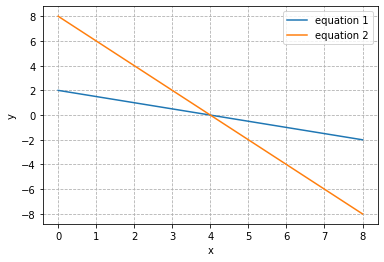

In [ ]:
import matplotlib.pyplot as plt
    
x = np.linspace( 0, 8, 100 )
y1 = 2 - x/2
y2 = 8 - 2*x
 
plt.plot( x, y1, label="equation 1" )
plt.plot( x, y2, label="equation 2" )
plt.xlabel("x")
plt.ylabel("y")
plt.grid( linestyle='--' )
plt.legend()

# Plot ausgeben:
#plt.show()

**Spezielle Matrizen**

In [ ]:
# Nullmatrix
N=np.zeros([3,4])
print("N_{3x4} = ", N)

# Einheitsmatrix
E=np.eye(4)
print("E_4 = ", E)

# Diagonalmatrix
D=np.diag([1,2,3])
print("D = ", D)

**Matrizenmultiplikation**

\begin{equation*}
 A = \begin{pmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{pmatrix}, \quad
 B = \begin{pmatrix} 1 & 4  & 7 & 10 \\ 2 & 5 & 8 & 11 \\ 3 & 6 & 9 & 12 \end{pmatrix}, \quad
 C = \begin{pmatrix} 1 & 0 & 1 \\ 0 & 1 & 0 \end{pmatrix}
\end{equation*}

In [ ]:
A = np.array([[1,2,3],[4,5,6]])
B = np.array([[1,4,7,10],[2,5,8,11],[3,6,9,12]])
C = np.array([[1,0,1],[0,1,0]])

print(A)
print(B)
print(C)

In [ ]:
# Möglichkeit 1:
AB = np.dot( A, B )
print(AB)

In [ ]:
# Möglichkeit 2:
AB = A.dot( B )
print(AB)

In [ ]:
# Möglichkeit 3: (Python >3.5)
AB = A @ B
print(AB)

**Elementweise Matrizenmultiplikation**

In [ ]:
AC = A*C
print(AC)

**Transponierte der Matrix**

In [ ]:
A = np.array([[1,2,3],[4,5,6]])
A.T